## <center> Prelims 2024
### <center> Mani Tyagi
#### <center> 200973108

In [8]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

### Part (c)

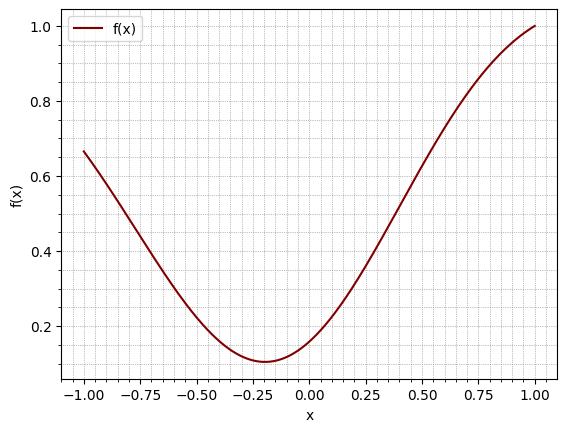

In [9]:
# defining and plotting the given function
def f(x):
    return np.exp(-x**2)*np.sin(x-1) + 1

# plotting the function
x = np.linspace(-1,1,400)
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.show()

### Part (c)

In [21]:
def legendre_polynomial(n, x):
    """
    ==============================================================================
    Calculate the Legendre polynomial of degree n at x.
    
    Parameters:
    - n : The degree of the Legendre polynomial.
    - x : The point(s) at which to evaluate the polynomial.
    
    Returns:
    - The value of the Legendre polynomial of degree n at x.
    ==============================================================================
    """
    if n == 0:
        return 1
    elif n == 1:
        return x
    elif n == 2:
        return 0.5 * (3*x**2 - 1)
    elif n == 3:
        return 0.5 * (5*x**3 - 3*x)
    elif n == 4:
        return (1/8.0) * (35*x**4 - 30*x**2 + 3)
    else:  # use recursion formula
        return ((2*n - 1) * x * legendre_polynomial(n-1, x) - (n - 1) * legendre_polynomial(n-2, x)) / n


def coefficients(n, x, f):
    """
    ==============================================================================
    Calculate the coefficients for the Legendre polynomial expansion of function f.
    
    Parameters:
    - n : The degree of the Legendre polynomial.
    - x : The point(s) at which to evaluate the polynomial.
    - f : The function to be approximated.
    
    Returns:
    - The coefficient of the nth Legendre polynomial in the expansion of f.
    ==============================================================================
    """
    
    # Define the integrand as a function of x
    def integrand(x):
        return f(x) * legendre_polynomial(n, x)
    
    # Perform the integration over the interval [-1, 1]
    I, _ = quad(integrand, -1, 1)
    
    return ((2*n+1)/2.0) * I

In [22]:
def print_coefficients(max_n, f):
    """
    ==============================================================================
    Print the coefficients of the Legendre polynomial expansion up to degree max_n for function f.
    
    Parameters:
    - max_n : The maximum degree of the Legendre polynomials.
    - f : The function to be approximated.
    
    Prints:
    - The coefficients of the Legendre polynomial expansion.
    ==============================================================================
    """    
    for n in range(max_n+1):
        c = coefficients(n, x, f)
        print(f"Coefficient c{n}: {c}")
        
print("-"*40)        
print_coefficients(4, f)        
print("-"*40)        

----------------------------------------
Coefficient c0: 0.44784831278662507
Coefficient c1: 0.28091490992363866
Coefficient c2: 0.4838938841641618
Coefficient c3: -0.13645674773391614
Coefficient c4: -0.11273025713192437
----------------------------------------


In [23]:
def construct_Pn(n, f):
    '''
    ----------------------------------------------------------------
    Fucntion to form the Legendre polynomial expansion
    ----------------------------------------------------------------
    '''
    # Compute the coefficients c_i for i in range(n+1)
    coeffs = [coefficients(i, x, f) for i in range(n+1)]
    
    # Define the polynomial function Pn(x)
    def Pn(x):
        return sum(c * legendre_polynomial(i, x) for i, c in enumerate(coeffs))
    
    return Pn

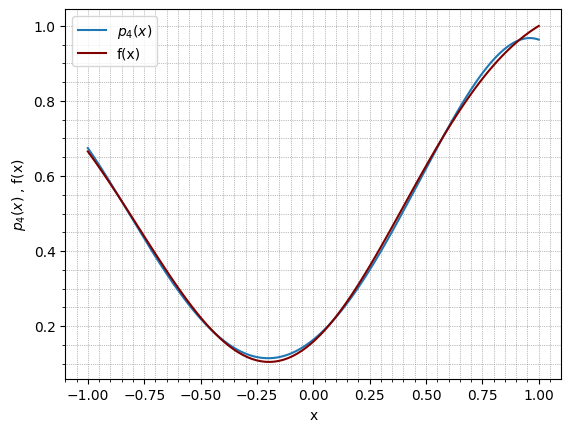

In [24]:
# Construct P4(x) 
Pn_function = construct_Pn(4, f)

# Generate x values and compute P4(x) values
x_values = np.linspace(-1, 1, 400)
Pn_values = [Pn_function(x) for x in x_values]

# Plot P4(x)
plt.plot(x_values, Pn_values, label="$p_4(x)$")
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('$p_4(x)$ , f(x)')
plt.xlabel('x')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

### Part (d)

In [29]:
def objective_function(c):
    """
    ===============================================================================================
    Calculates the objective function value for a given set of coefficients (c).

    Parameters:
        c : coefficients for the Legendre polynomial approximation.

    Returns:
        The value of the objective function, representing the squared error.
    ================================================================================================
    """
    n = len(c)
    integral_terms = np.zeros(n)
    
    for i in range(n):
        terms = np.array([c[j] * legendre_polynomial(j, x) for j in range(n)]) 
        integral_terms[i] = np.trapz(f(x) - np.sum(terms, axis=0), x) ** 2
    
    return np.sum(integral_terms)



def gradient(c):
    '''
    ======================================================================
    Calculates the gradient of the objective function W
    
    Parameters:
        c : coefficients for the Legendre polynomial approximation. 
    ======================================================================
    '''
    n = len(c)
    grad = np.zeros(n)
    for i in range(n):
        integral_term = np.trapz(f(x) * legendre_polynomial(i, x), x) - 2 * c[i] / (2 * i + 1)
        grad[i] = -2 * integral_term
    return grad



def approximated_f(x, c):
    ''' 
    ===========================================================
    Calculates the approximated function using optimized c
    ===========================================================
    '''
    n = len(c)
    approx_f = np.sum([c[i] * legendre_polynomial(i, x) for i in range(n)], axis=0)
    return approx_f


In [34]:
# Domain for plotting
x = np.linspace(-1, 1, 100)

# Initial guess for coefficients c_i
max_n = 4
initial_guess = np.zeros(max_n+1)

# Minimize W using gradients
result = minimize(objective_function, initial_guess, jac=gradient, method='BFGS')

# Extract the optimized coefficients
optimal_c = result.x
print("-"*30)
print("Optimized coefficients:")
print("-"*30)

for n in range(max_n+1):
    print(f"c{n}: {optimal_c[n]}")
print("-"*30)


------------------------------
Optimized coefficients:
------------------------------
c0: 0.4478686737695029
c1: 0.2809144444406612
c2: 0.4844153372676482
c3: -0.13626722666974048
c4: -0.10999294494482652
------------------------------


/tmp/ipykernel_1186068/1881729480.py:17: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  terms = np.array([c[j] * legendre_polynomial(j, x) for j in range(n)])


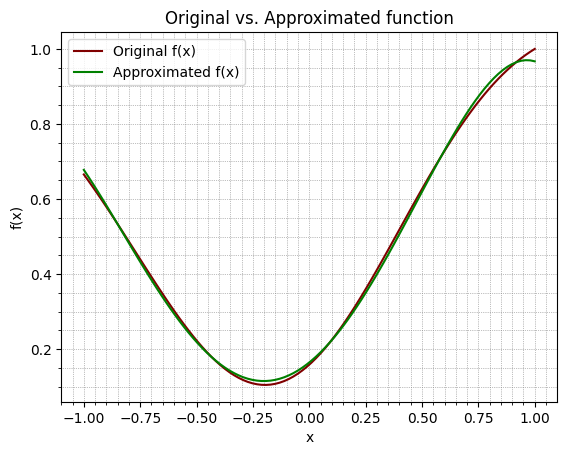

In [17]:
# Plot original and approximated functions
plt.plot(x, f(x), label='Original f(x)', color='maroon')
plt.plot(x, approximated_f(x, optimal_c), label='Approximated f(x)', color='green')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Original vs. Approximated function')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

### Part (e)